**MACHINE LEARNING 23CSE301 LAB ACTIVITY 3 — DECISION TREE CLASSIFIER**

**Question 1:** In a classification tree, the data set splits according to its variables. In this scenario, age and income determine whether someone buys a house. If training data tells us that 70 percent of people over age 30 bought a house, then the data gets split there, with age becoming the first node in the tree. This split makes the data 80 percent “pure.” The second node then addresses income from there.

**Dataset used:** Customer_Attributes_and_Purchase_Propensity.csv

**Note:** The uploaded dataset contains Age, Income, and a binary Purchased target, so it is structurally suitable for a two-feature decision-tree classification exercise. However, the dataset does **not** explicitly identify the purchase as a house purchase, and its actual data does not show the stated 70% purchase rate for people over age 30. The notebook therefore uses the real uploaded values and lets the Decision Tree choose the best split automatically.

### Importing Required Libraries

In [5]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
import seaborn as sn
import matplotlib.pyplot as plt

### Generating (Reading) the Dataset

In [6]:
dataset_path = 'Customer_Attributes_and_Purchase_Propensity.csv'

data = pd.read_csv(dataset_path)

print(data.shape)
data.head()

(500, 6)


,Age,Income,City,Marital_Status,Score,Purchased
0,56,24000,Houston,Divorced,0.479897,0
1,46,90588,Chicago,Single,0.685968,1
2,32,113610,Houston,Divorced,0.017380,0
3,60,117856,New York,Married,0.323131,0
4,25,58304,Houston,Single,0.973098,0


### Checking for any null values in dataset

In [7]:
data.isnull().sum()

Age               0
Income            0
City              0
Marital_Status    0
Score             0
Purchased         0
dtype: int64

### Checking the Target Variable

In [8]:
print('Purchased value counts:')
print(data['Purchased'].value_counts())

print('\nTarget classes:')
print(sorted(data['Purchased'].unique()))

Purchased value counts:
Purchased
1    267
0    233
Name: count, dtype: int64

Target classes:
[np.int64(0), np.int64(1)]


### Verifying the 70% statement in the given question

The question describes a situation where 70 percent of people over age 30 bought a house. We should verify that statement against the **uploaded dataset** rather than assume it is true.

In [9]:
over_30_purchase_rate = data.loc[data['Age'] > 30, 'Purchased'].mean() * 100
age_30_or_less_purchase_rate = data.loc[data['Age'] <= 30, 'Purchased'].mean() * 100

print('Purchase percentage for Age > 30 :', round(over_30_purchase_rate, 2), '%')
print('Purchase percentage for Age <= 30:', round(age_30_or_less_purchase_rate, 2), '%')

Purchase percentage for Age > 30 : 53.74 %
Purchase percentage for Age <= 30: 52.38 %


### Assigning Dependent and Independent Variables

In [10]:
feature_cols = ['Age', 'Income']
x = data[feature_cols]
y = data['Purchased']

### Splitting the dataset into Training and Testing Dataset

In [11]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=5
)

display(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

(400, 2)

(400,)

(100, 2)

(100,)

### Fitting the Model (Decision Tree Classifier)

In [12]:
model = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=5)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print('y_pred: ', y_pred)

y_pred:  [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1
 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


### Checking the Root Node Chosen by the Model

In [13]:
root_feature = feature_cols[model.tree_.feature[0]]
root_threshold = model.tree_.threshold[0]

print('Root Node Feature :', root_feature)
print('Root Node Threshold:', root_threshold)
print('Tree Depth         :', model.get_depth())
print('Number of Leaf Nodes:', model.get_n_leaves())

Root Node Feature : Income
Root Node Threshold: 20954.0
Tree Depth         : 3
Number of Leaf Nodes: 5


### Evaluation Metrics

In [14]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)
print('Confusion Matrix : ', conf_mat)

Accuracy_score = metrics.accuracy_score(y_test, y_pred)
print('Accuracy Score : ', Accuracy_score)
print('Accuracy in Percentage : ', int(Accuracy_score * 100), '%')

Confusion Matrix :  [[ 2 43]
 [ 3 52]]
Accuracy Score :  0.54
Accuracy in Percentage :  54 %


[Text(0.5, 1.0, 'Decision Tree [ Age, Income -> Purchased ]')]

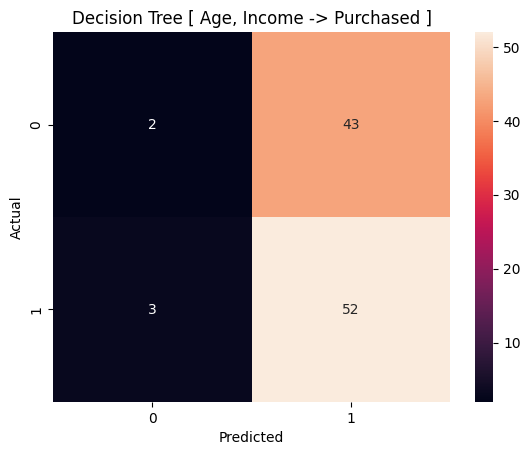

In [15]:
conf_mat = pd.crosstab(
    y_test, y_pred,
    rownames=['Actual'],
    colnames=['Predicted']
)

sn.heatmap(conf_mat, annot=True).set(
    title='Decision Tree [ Age, Income -> Purchased ]'
)

### Visualizing the Decision Tree

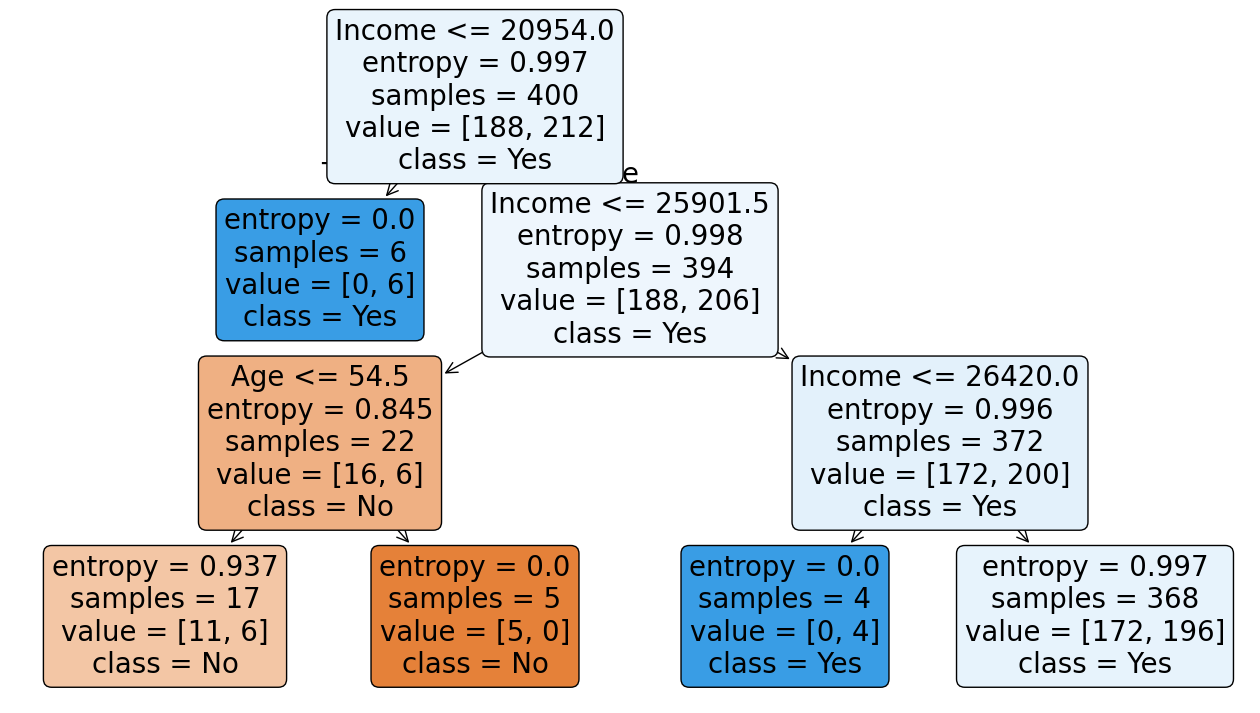

In [16]:
plt.figure(figsize=(16, 9))
tree.plot_tree(
    model,
    feature_names=feature_cols,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True
)
plt.show()

### Interpretation

- `Age` and `Income` are the only independent variables used, matching the two-variable setup in the question.
- `Purchased` is the binary dependent variable.
- The Decision Tree uses **entropy** to choose the split that reduces impurity the most.
- The root node is selected automatically by the algorithm; we do not manually force `Age` to be the first node.
- Therefore, the uploaded dataset is suitable for demonstrating the coding procedure, but the actual split chosen by the model can differ from the illustrative statement in the question.